# Demo Thuật Toán Apriori - Khai Phá Luật Kết Hợp

Notebook này minh họa thuật toán Apriori cho khai phá itemset phổ biến và sinh luật kết hợp từ dữ liệu giao dịch.

**Nội dung:**
1. Import thư viện cần thiết
2. Nạp và chuẩn bị dữ liệu
3. Chạy thuật toán Apriori
4. Phân tích itemset phổ biến
5. Sinh luật kết hợp
6. Trực quan hóa kết quả
7. Xuất thống kê và biểu đồ


## 1. Import Thư Viện Cần Thiết

In [160]:
import sys
import os
import json
import csv
import time
from pathlib import Path
from collections import defaultdict
from typing import List, Set, Dict, Tuple
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn project vào sys.path
project_root = Path().cwd().parent
sys.path.insert(0, str(project_root))

# Import các module từ project
from src.algorithms.apriori import Apriori

# Optional imports
try:
    from src.mining.frequent_itemset import FrequentItemsetManager
    from src.mining.rule_generation import generate_association_rules, filter_rules, sort_rules, get_rules_summary
    from src.evaluation.metrics import MetricsAnalyzer, SupportMetric, ConfidenceMetric, LiftMetric
except ImportError as e:
    print(f"Warning: Could not import all mining modules: {e}")

try:
    from src.evaluation.compare import AlgorithmResult
except ImportError:
    pass

try:
    from src.mining import DatasetLoader
except ImportError:
    DatasetLoader = None

# Cấu hình visualization
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Tạo thư mục outputs
output_dir = project_root / 'outputs' / 'apriori'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Project root: {project_root}")
print(f"✓ Output directory: {output_dir}")
print("✓ Thư viện đã import thành công!")


✓ Project root: /Users/nangvuong/Desktop/association-rule-project
✓ Output directory: /Users/nangvuong/Desktop/association-rule-project/outputs/apriori
✓ Thư viện đã import thành công!


In [161]:
# Reload modules để đảm bảo sử dụng code mới nhất
import importlib
import sys

# Reload modules
for module_name in list(sys.modules.keys()):
    if 'src' in module_name:
        del sys.modules[module_name]

# Import lại
from src.algorithms.apriori import Apriori

print("✓ Modules reloaded successfully!")

✓ Modules reloaded successfully!


## 2. Nạp và Chuẩn Bị Dữ Liệu

In [162]:
# Nạp dữ liệu từ thư mục processed
from src.mining import DatasetLoader

data_dir = project_root / 'data' / 'processed'

try:
    loader = DatasetLoader(data_dir)
    transactions = loader.load_transactions()
    total_transactions = len(transactions)
    
    print(f"\n{'='*70}")
    print("THỐNG KÊ DỮ LIỆU")
    print(f"{'='*70}")
    print(f"Tổng số giao dịch: {total_transactions}")
    
    # Tính toán các thống kê về giao dịch
    transaction_sizes = [len(t) for t in transactions]
    unique_items = set()
    for t in transactions:
        unique_items.update(t)
    
    print(f"Tổng số item duy nhất: {len(unique_items)}")
    print(f"Kích thước giao dịch - Min: {min(transaction_sizes)}, Max: {max(transaction_sizes)}, Avg: {np.mean(transaction_sizes):.2f}")
    
    # Hiển thị một số giao dịch mẫu
    print(f"\nSample 5 giao dịch đầu tiên:")
    for i, trans in enumerate(transactions[:5]):
        print(f"  {i+1}. {sorted(list(trans))}")

except Exception as e:
    print(f"❌ Error loading data: {e}")
    print(f"Make sure data files exist in: {data_dir}")
    transactions = []
    total_transactions = 0
    unique_items = set()
    transaction_sizes = []


THỐNG KÊ DỮ LIỆU
Tổng số giao dịch: 14070
Tổng số item duy nhất: 177
Kích thước giao dịch - Min: 2, Max: 58, Avg: 7.67

Sample 5 giao dịch đầu tiên:
  1. ['ASSORTED COLOUR BIRD ORNAMENT', 'HEART FILIGREE DOVE LARGE', 'HEART IVORY TRELLIS LARGE', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'SCOTTIE DOG HOT WATER BOTTLE']
  2. ['CHOCOLATE HOT WATER BOTTLE', 'FELTCRAFT DOLL ROSIE', 'HANGING HEART ZINC T-LIGHT HOLDER', 'PINK BLUE FELT CRAFT TRINKET BOX', 'SCOTTIE DOG HOT WATER BOTTLE']
  3. ['BAKING SET 9 PIECE RETROSPOT', 'POSTAGE', 'RED TOADSTOOL LED NIGHT LIGHT', 'RETRO SPOT TEA SET CERAMIC 11 PC']
  4. ['BAKING SET 9 PIECE RETROSPOT', 'RED WOOLLY HOTTIE WHITE HEART.', 'SCOTTIE DOG HOT WATER BOTTLE']
  5. ['FELTCRAFT DOLL ROSIE', 'HEART IVORY TRELLIS LARGE', 'SCOTTIE DOG HOT WATER BOTTLE', 'VINTAGE SNAP CARDS', 'WHITE HANGING HEART T-LIGHT HOLDER']


## 3. Chạy Thuật Toán Apriori

In [163]:
from dotenv import load_dotenv

# Nạp các tham số từ .env
env_file = project_root / '.env'
load_dotenv(env_file)

# Đọc các tham số từ biến môi trường
min_support = int(os.getenv('MINING_MIN_SUPPORT', 100))
min_confidence = float(os.getenv('MINING_MIN_CONFIDENCE', 0.5))
use_hash_tree = True

print(f"\n{'='*70}")
print("CHẠY APRIORI")
print(f"{'='*70}")
print(f"📋 Tham số được nạp từ .env file: {env_file}")
print(f"Tham số: min_support={min_support}, min_confidence={min_confidence}")
print(f"Hash Tree: {use_hash_tree}")
if use_hash_tree:
    print(f"  (Các tham số HashTree tự động load từ .env)\n")

# Chạy Apriori
apriori = Apriori(
    min_support=min_support, 
    min_confidence=min_confidence, 
    use_hash_tree=use_hash_tree
)
apriori_result = apriori.fit(transactions)

# Lưu kết quả
frequent_itemsets = apriori_result['frequent_itemsets']
support_counts = apriori_result['support_counts']
total_itemsets = apriori_result['total_itemsets']
execution_time = apriori_result['execution_time']

print(f"\n✓ Execution time: {execution_time:.4f} seconds")
print(f"✓ Total itemsets: {total_itemsets}")


CHẠY APRIORI
📋 Tham số được nạp từ .env file: /Users/nangvuong/Desktop/association-rule-project/.env
Tham số: min_support=100, min_confidence=0.5
Hash Tree: True
  (Các tham số HashTree tự động load từ .env)

THUẬT TOÁN APRIORI - KHAI PHÁ ITEMSET PHỔ BIẾN
Số giao dịch: 14070
Support tối thiểu: 100

Cấp độ 1: Tìm thấy 177 1-itemset phổ biến
Cấp độ 2: Sinh 15576 candidates
  [Hash Tree] Đã xử lý 2814/14070 transactions...
  [Hash Tree] Đã xử lý 5628/14070 transactions...
  [Hash Tree] Đã xử lý 8442/14070 transactions...
  [Hash Tree] Đã xử lý 11256/14070 transactions...
  [Hash Tree] Đã xử lý 14070/14070 transactions...
Cấp độ 2: Tìm thấy 760 itemset phổ biến
Cấp độ 3: Sinh 1975 candidates
  [Hash Tree] Đã xử lý 2814/14070 transactions...
  [Hash Tree] Đã xử lý 5628/14070 transactions...
  [Hash Tree] Đã xử lý 8442/14070 transactions...
  [Hash Tree] Đã xử lý 11256/14070 transactions...
  [Hash Tree] Đã xử lý 14070/14070 transactions...
Cấp độ 3: Tìm thấy 198 itemset phổ biến
Cấp độ 4: 

## 4. Phân Tích Itemset Phổ Biến

In [164]:
# Tạo bảng thống kê itemsets theo kích thước
itemset_stats = []
for size in sorted(frequent_itemsets.keys()):
    count = len(frequent_itemsets[size])
    itemset_stats.append({
        'Kích thước': size,
        'Số lượng': count,
        'Phần trăm': f"{(count/total_itemsets)*100:.1f}%"
    })

itemset_df = pd.DataFrame(itemset_stats)
print(f"\n{'='*70}")
print("PHÂN BỐ ITEMSETS THEO KÍCH THƯỚC")
print(f"{'='*70}")
print(itemset_df.to_string(index=False))

# Tính toán phân bố support
support_values = list(support_counts.values())
support_stats = {
    'Min': min(support_values),
    'Max': max(support_values),
    'Mean': np.mean(support_values),
    'Median': np.median(support_values),
    'Std': np.std(support_values)
}

print(f"\n{'='*70}")
print("PHÂN BỐ SUPPORT")
print(f"{'='*70}")
for key, value in support_stats.items():
    print(f"{key:10s}: {value:.2f}")

# Hiển thị top 10 itemsets theo support
print(f"\n{'='*70}")
print("TOP 10 ITEMSETS THEO SUPPORT")
print(f"{'='*70}")
top_itemsets = sorted(support_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for i, (itemset, support) in enumerate(top_itemsets, 1):
    pct = (support / total_transactions) * 100
    print(f"{i:2d}. {str(itemset):30s} - Support: {support:4d} ({pct:.2f}%)")


PHÂN BỐ ITEMSETS THEO KÍCH THƯỚC
 Kích thước  Số lượng Phần trăm
          1       177     15.2%
          2       760     65.1%
          3       198     17.0%
          4        31      2.7%
          5         1      0.1%

PHÂN BỐ SUPPORT
Min       : 100.00
Max       : 2904.00
Mean      : 227.16
Median    : 144.00
Std       : 204.55

TOP 10 ITEMSETS THEO SUPPORT
 1. ('WHITE HANGING HEART T-LIGHT HOLDER',) - Support: 2904 (20.64%)
 2. ('REGENCY CAKESTAND 3 TIER',)  - Support: 1580 (11.23%)
 3. ('STRAWBERRY CERAMIC TRINKET BOX',) - Support: 1296 (9.21%)
 4. ('ASSORTED COLOUR BIRD ORNAMENT',) - Support: 1284 (9.13%)
 5. ('HOME BUILDING BLOCK WORD',)  - Support: 1155 (8.21%)
 6. ('PACK OF 72 RETRO SPOT CAKE CASES',) - Support: 1155 (8.21%)
 7. ('60 TEATIME FAIRY CAKE CASES',) - Support: 1133 (8.05%)
 8. ('LUNCH BAG RED SPOTTY',)      - Support: 1056 (7.51%)
 9. ('JUMBO BAG RED RETROSPOT',)   - Support: 1042 (7.41%)
10. ('REX CASH+CARRY JUMBO SHOPPER',) - Support:  999 (7.10%)


## 5. Sinh Luật Kết Hợp

In [165]:
# Sinh luật kết hợp sử dụng apriori.generate_rules()
rules_dict = apriori.generate_rules()

print(f"\n{'='*70}")
print("SINH LUẬT KẾT HỢP")
print(f"{'='*70}")
print(f"Tổng luật sinh được: {len(rules_dict)}")

# Tính toán thống kê về luật
if rules_dict:
    confidences = [r['confidence'] for r in rules_dict]
    lifts = [r['lift'] for r in rules_dict]
    
    print(f"\nThống kê Confidence:")
    print(f"  Min: {min(confidences):.4f}")
    print(f"  Max: {max(confidences):.4f}")
    print(f"  Mean: {np.mean(confidences):.4f}")
    
    print(f"\nThống kê Lift:")
    print(f"  Min: {min(lifts):.4f}")
    print(f"  Max: {max(lifts):.4f}")
    print(f"  Mean: {np.mean(lifts):.4f}")
    
    # Hiển thị top 10 luật theo confidence
    print(f"\n{'='*70}")
    print("TOP 10 LUẬT THEO CONFIDENCE")
    print(f"{'='*70}")
    
    top_rules = sorted(rules_dict, key=lambda x: x['confidence'], reverse=True)[:10]
    for i, rule in enumerate(top_rules, 1):
        antecedent = ', '.join(rule['antecedent'])
        consequent = ', '.join(rule['consequent'])
        print(f"{i:2d}. {{{antecedent}}} => {{{consequent}}}")
        print(f"    Support: {rule['support']}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}\n")


SINH LUẬT KẾT HỢP
Tổng luật sinh được: 457

Thống kê Confidence:
  Min: 0.5000
  Max: 0.9344
  Mean: 0.6159

Thống kê Lift:
  Min: 2.5768
  Max: 37.7026
  Mean: 11.0254

TOP 10 LUẬT THEO CONFIDENCE
 1. {WHITE HANGING HEART T-LIGHT HOLDER, WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH} => {WOODEN FRAME ANTIQUE WHITE}
    Support: 114, Confidence: 0.9344, Lift: 13.2534

 2. {WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH} => {WOODEN FRAME ANTIQUE WHITE}
    Support: 191, Confidence: 0.9183, Lift: 13.0242

 3. {WHITE HANGING HEART T-LIGHT HOLDER, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN FRAME ANTIQUE WHITE, WOODEN PICTURE FRAME WHITE FINISH} => {WOOD 2 DRAWER CABINET WHITE FINISH}
    Support: 114, Confidence: 0.9120, Lift: 22.2004

 4. {CERAMIC STRAWBERRY CAKE MONEY BANK, SWEETHEART CERAMIC TRINKET BOX} => {STRAWBERRY CERAMIC TRINKET BOX}
    Support: 127, Confidence: 0.

## 6. Trực Quan Hóa Kết Quả

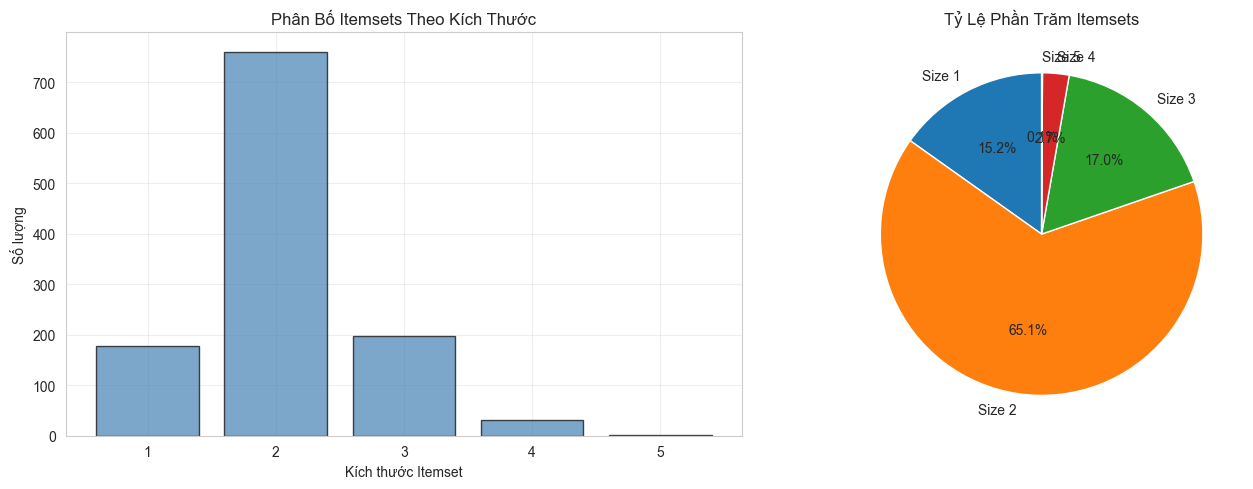

✓ Saved: itemset_distribution.png


In [166]:
### 6.1 Phân Bố Itemsets Theo Kích Thước

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - số lượng itemsets
sizes = sorted(frequent_itemsets.keys())
counts = [len(frequent_itemsets[s]) for s in sizes]

axes[0].bar(sizes, counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Kích thước Itemset')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Phân Bố Itemsets Theo Kích Thước')
axes[0].grid(True, alpha=0.3)

# Pie chart - phần trăm
axes[1].pie(counts, labels=[f'Size {s}' for s in sizes], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ Lệ Phần Trăm Itemsets')

plt.tight_layout()
plt.savefig(output_dir / 'itemset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: itemset_distribution.png")

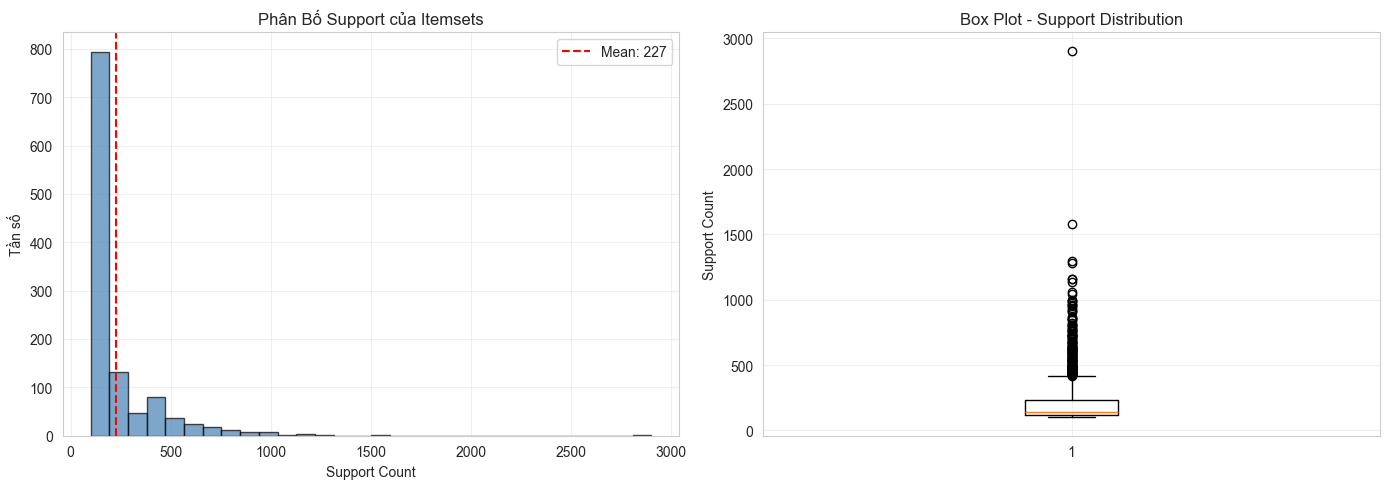

✓ Saved: support_distribution.png


In [167]:
### 6.2 Phân Bố Support

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - support distribution
axes[0].hist(support_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Support Count')
axes[0].set_ylabel('Tần số')
axes[0].set_title('Phân Bố Support của Itemsets')
axes[0].axvline(np.mean(support_values), color='red', linestyle='--', label=f'Mean: {np.mean(support_values):.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(support_values, vert=True)
axes[1].set_ylabel('Support Count')
axes[1].set_title('Box Plot - Support Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'support_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: support_distribution.png")

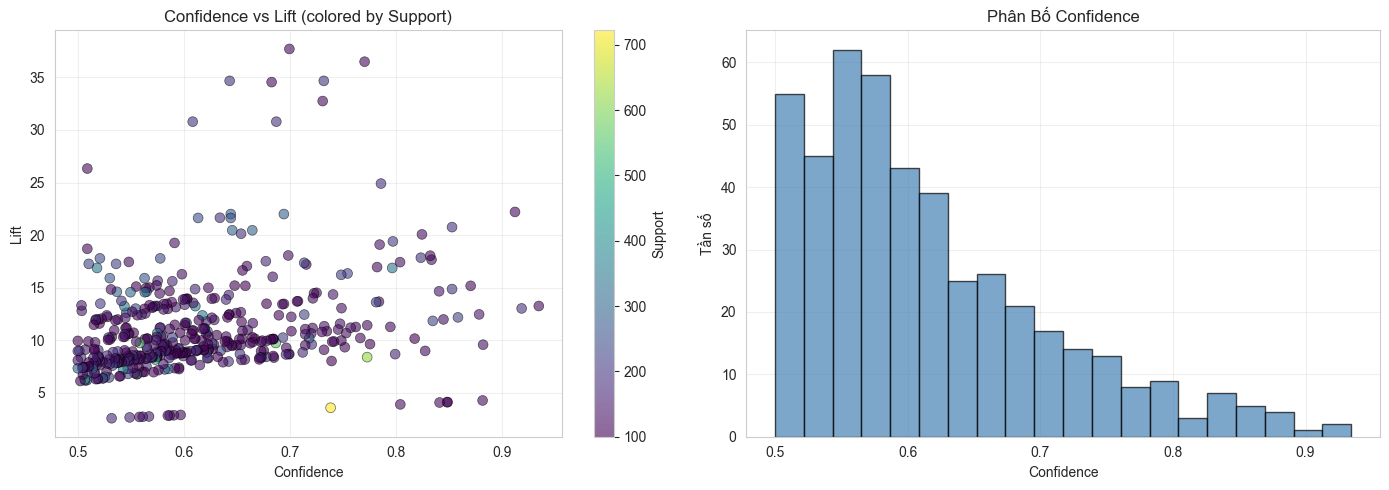

✓ Saved: rules_metrics.png


In [168]:
### 6.3 Scatter Plot - Confidence vs Lift

if rules_dict:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    confidences = [r['confidence'] for r in rules_dict]
    lifts = [r['lift'] for r in rules_dict]
    supports = [r['support'] for r in rules_dict]
    
    # Scatter plot - Confidence vs Lift (colored by support)
    scatter = axes[0].scatter(confidences, lifts, c=supports, cmap='viridis', 
                             alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Lift')
    axes[0].set_title('Confidence vs Lift (colored by Support)')
    axes[0].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[0])
    cbar.set_label('Support')
    
    # Histogram - Confidence distribution
    axes[1].hist(confidences, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Tần số')
    axes[1].set_title('Phân Bố Confidence')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'rules_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: rules_metrics.png")

## 7. Xuất Thống Kê và Biểu Đồ

In [169]:
### 7.1 Xuất Itemsets

# Tạo DataFrame từ frequent itemsets
itemset_records = []
for itemset, support in support_counts.items():
    support_pct = (support / total_transactions) * 100
    itemset_records.append({
        'Itemset': ', '.join(itemset),
        'Size': len(itemset),
        'Support_Count': support,
        'Support_Percentage': f"{support_pct:.2f}%",
        'Support_Decimal': support / total_transactions
    })

itemset_df_export = pd.DataFrame(itemset_records)

# Lưu vào CSV
itemset_file = output_dir / 'frequent_itemsets.csv'
itemset_df_export.to_csv(itemset_file, index=False)
print(f"✓ Saved: frequent_itemsets.csv ({len(itemset_records)} itemsets)")

# Hiển thị sample
print(f"\nSample 10 dòng:")
print(itemset_df_export.head(10).to_string(index=False))

✓ Saved: frequent_itemsets.csv (1167 itemsets)

Sample 10 dòng:
                          Itemset  Size  Support_Count Support_Percentage  Support_Decimal
        HEART IVORY TRELLIS LARGE     1            479              3.40%         0.034044
     SCOTTIE DOG HOT WATER BOTTLE     1            854              6.07%         0.060697
        HEART FILIGREE DOVE LARGE     1            417              2.96%         0.029638
    ASSORTED COLOUR BIRD ORNAMENT     1           1284              9.13%         0.091258
         LOVE BUILDING BLOCK WORD     1            939              6.67%         0.066738
         HOME BUILDING BLOCK WORD     1           1155              8.21%         0.082090
             FELTCRAFT DOLL ROSIE     1            437              3.11%         0.031059
       CHOCOLATE HOT WATER BOTTLE     1            791              5.62%         0.056219
 PINK BLUE FELT CRAFT TRINKET BOX     1            562              3.99%         0.039943
HANGING HEART ZINC T-LIGHT

In [170]:
### 7.2 Xuất Luật Kết Hợp

if rules_dict:
    # Tạo DataFrame từ rules
    rule_records = []
    for rule in rules_dict:
        rule_records.append({
            'Antecedent': ', '.join(rule['antecedent']),
            'Consequent': ', '.join(rule['consequent']),
            'Support': rule['support'],
            'Support_Percentage': f"{(rule['support']/total_transactions)*100:.2f}%",
            'Confidence': f"{rule['confidence']:.4f}",
            'Lift': f"{rule['lift']:.4f}"
        })
    
    rule_df_export = pd.DataFrame(rule_records)
    
    # Lưu vào CSV
    rule_file = output_dir / 'association_rules.csv'
    rule_df_export.to_csv(rule_file, index=False)
    print(f"✓ Saved: association_rules.csv ({len(rule_records)} rules)")
    
    # Hiển thị sample
    print(f"\nSample 10 luật hàng đầu:")
    print(rule_df_export.head(10).to_string(index=False))
else:
    print("Không có luật nào được sinh ra với tham số hiện tại")

✓ Saved: association_rules.csv (457 rules)

Sample 10 luật hàng đầu:
                                                                                                                                  Antecedent                         Consequent  Support Support_Percentage Confidence    Lift
WHITE HANGING HEART T-LIGHT HOLDER, WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH         WOODEN FRAME ANTIQUE WHITE      114              0.81%     0.9344 13.2534
                                    WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH         WOODEN FRAME ANTIQUE WHITE      191              1.36%     0.9183 13.0242
        WHITE HANGING HEART T-LIGHT HOLDER, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN FRAME ANTIQUE WHITE, WOODEN PICTURE FRAME WHITE FINISH WOOD 2 DRAWER CABINET WHITE FINISH      114              0.81%     0.9120 22.2004
                                       

In [171]:
### 7.3 Xuất Báo Cáo Thống Kê

# Tạo báo cáo tóm tắt
report = {
    'Timestamp': pd.Timestamp.now().isoformat(),
    'Algorithm': 'Apriori',
    'Parameters': {
        'min_support': min_support,
        'min_confidence': min_confidence,
        'use_hash_tree': use_hash_tree
    },
    'Dataset': {
        'total_transactions': total_transactions,
        'unique_items': len(unique_items),
        'avg_transaction_size': float(np.mean(transaction_sizes)),
        'min_transaction_size': int(min(transaction_sizes)),
        'max_transaction_size': int(max(transaction_sizes))
    },
    'Results': {
        'total_itemsets': total_itemsets,
        'total_rules': len(rules_dict) if rules_dict else 0,
        'execution_time': float(execution_time),
        'itemsets_by_size': {str(k): v for k, v in itemset_stats[0].items() if k != 'Phần trăm'}
    },
    'Support_Stats': {
        'min': float(support_stats['Min']),
        'max': float(support_stats['Max']),
        'mean': float(support_stats['Mean']),
        'median': float(support_stats['Median']),
        'std': float(support_stats['Std'])
    }
}

if rules_dict:
    report['Confidence_Stats'] = {
        'min': float(min([r['confidence'] for r in rules_dict])),
        'max': float(max([r['confidence'] for r in rules_dict])),
        'mean': float(np.mean([r['confidence'] for r in rules_dict]))
    }
    report['Lift_Stats'] = {
        'min': float(min([r['lift'] for r in rules_dict])),
        'max': float(max([r['lift'] for r in rules_dict])),
        'mean': float(np.mean([r['lift'] for r in rules_dict]))
    }

# Xuất thống kê thành CSV
stats_data = {
    'Metric': [
        'Algorithm',
        'Timestamp',
        'Total Transactions',
        'Unique Items',
        'Avg Transaction Size',
        'Min Transaction Size',
        'Max Transaction Size',
        'Min Support (threshold)',
        'Min Confidence (threshold)',
        'Use Hash Tree',
        'Total Itemsets Found',
        'Total Rules Generated',
        'Execution Time (seconds)',
        'Support - Min',
        'Support - Max',
        'Support - Mean',
        'Support - Median',
        'Support - Std Dev'
    ],
    'Value': [
        report['Algorithm'],
        report['Timestamp'],
        report['Dataset']['total_transactions'],
        report['Dataset']['unique_items'],
        f"{report['Dataset']['avg_transaction_size']:.2f}",
        report['Dataset']['min_transaction_size'],
        report['Dataset']['max_transaction_size'],
        report['Parameters']['min_support'],
        report['Parameters']['min_confidence'],
        report['Parameters']['use_hash_tree'],
        report['Results']['total_itemsets'],
        report['Results']['total_rules'],
        f"{report['Results']['execution_time']:.4f}",
        f"{report['Support_Stats']['min']:.2f}",
        f"{report['Support_Stats']['max']:.2f}",
        f"{report['Support_Stats']['mean']:.2f}",
        f"{report['Support_Stats']['median']:.2f}",
        f"{report['Support_Stats']['std']:.2f}"
    ]
}

# Thêm thống kê confidence và lift nếu có
if rules_dict:
    stats_data['Metric'].extend([
        'Confidence - Min',
        'Confidence - Max',
        'Confidence - Mean',
        'Lift - Min',
        'Lift - Max',
        'Lift - Mean'
    ])
    stats_data['Value'].extend([
        f"{report['Confidence_Stats']['min']:.4f}",
        f"{report['Confidence_Stats']['max']:.4f}",
        f"{report['Confidence_Stats']['mean']:.4f}",
        f"{report['Lift_Stats']['min']:.4f}",
        f"{report['Lift_Stats']['max']:.4f}",
        f"{report['Lift_Stats']['mean']:.4f}"
    ])

stats_df = pd.DataFrame(stats_data)
stats_csv_file = output_dir / 'statistics.csv'
stats_df.to_csv(stats_csv_file, index=False, encoding='utf-8-sig')
print(f"✓ Saved: statistics.csv")

print(f"\nBáo cáo thống kê:")
print(stats_df.to_string(index=False))


✓ Saved: statistics.csv

Báo cáo thống kê:
                    Metric                      Value
                 Algorithm                    Apriori
                 Timestamp 2026-05-05T09:33:12.985074
        Total Transactions                      14070
              Unique Items                        177
      Avg Transaction Size                       7.67
      Min Transaction Size                          2
      Max Transaction Size                         58
   Min Support (threshold)                        100
Min Confidence (threshold)                        0.5
             Use Hash Tree                       True
      Total Itemsets Found                       1167
     Total Rules Generated                        457
  Execution Time (seconds)                     4.4978
             Support - Min                     100.00
             Support - Max                    2904.00
            Support - Mean                     227.16
          Support - Median             

In [172]:
### 7.4 Tóm Tắt Kết Quả

print(f"\n{'='*70}")
print("TÓM TẮT KẾT QUẢ")
print(f"{'='*70}")
print(f"\n📊 APRIORI ALGORITHM EXECUTION SUMMARY")
print(f"\nOutput Directory: {output_dir}")
print(f"\n📁 Files Generated:")

# Liệt kê các file đã lưu
output_files = list(output_dir.glob('*'))
for i, file in enumerate(sorted(output_files), 1):
    size = file.stat().st_size
    if size > 1024*1024:
        size_str = f"{size/(1024*1024):.1f}MB"
    elif size > 1024:
        size_str = f"{size/1024:.1f}KB"
    else:
        size_str = f"{size}B"
    print(f"  {i}. {file.name:30s} ({size_str})")

print(f"\n📈 STATISTICS:")
print(f"  • Total Itemsets Found: {total_itemsets}")
print(f"  • Total Rules Generated: {len(rules_dict) if rules_dict else 0}")
print(f"  • Execution Time: {execution_time:.4f}s")
print(f"  • Itemsets/Second: {total_itemsets/execution_time:.2f}")

print(f"\n✅ Demo hoàn thành! Kết quả đã được lưu tại {output_dir}")
print(f"{'='*70}")


TÓM TẮT KẾT QUẢ

📊 APRIORI ALGORITHM EXECUTION SUMMARY

Output Directory: /Users/nangvuong/Desktop/association-rule-project/outputs/apriori

📁 Files Generated:
  1. association_rules.csv          (51.8KB)
  2. frequent_itemsets.csv          (105.9KB)
  3. itemset_distribution.png       (151.9KB)
  4. rules_metrics.png              (495.5KB)
  5. statistics.csv                 (592B)
  6. support_distribution.png       (141.6KB)

📈 STATISTICS:
  • Total Itemsets Found: 1167
  • Total Rules Generated: 457
  • Execution Time: 4.4978s
  • Itemsets/Second: 259.46

✅ Demo hoàn thành! Kết quả đã được lưu tại /Users/nangvuong/Desktop/association-rule-project/outputs/apriori
